# Jev-based Protein Binder Classification

In [2]:
from datasets import load_dataset
from simple_jev import *

In [3]:
## Get Anthropic Claude Protein Binder Design Dataset
ds_df = load_dataset("Anthropic/claude-protein-binder-design", "design_summary", split="full").to_pandas()

## Remove unnecessary columns
cols_to_keep = [
    "uuid",
    "target",
    "binder_length",
    # "sequence",
    "generator",
    "sequence_design_method",
    # "ipsae_min_boltz2",
    # "sc_dockq_boltz2",
    "epitope_n_residues",
    "adaptyv_binding"
]
ds_df = ds_df[cols_to_keep]

## Drop rows with missing values
ds_df = ds_df.dropna()
ds_df = ds_df.rename(columns={"adaptyv_binding": "y_true"})

## Filter to rows where y_true is "non_binder" or "binder"
ds_df = ds_df[ds_df["y_true"].isin(["non_binder", "binder"])]

ds_df.head()

,uuid,target,binder_length,generator,sequence_design_method,epitope_n_residues,y_true
0,816028de-2070-58fc-855d-889401037a4e,BBF-14,80,RFdiffusion3,SolubleMPNN,19,non_binder
1,1d5855c0-9c16-5c16-b81c-76eec408e06a,BBF-14,80,RFdiffusion3,SolubleMPNN,16,non_binder
2,8e55f8bf-e0d3-549d-a335-af4b1ee836fc,BBF-14,80,RFdiffusion3,SolubleMPNN,16,non_binder
3,990a6d64-7947-5775-ac23-3724d3c6f619,BBF-14,90,PXDesign,SolubleMPNN,16,non_binder
5,28b4db44-e64a-5b58-a2ef-9825cb336aba,BBF-14,90,PXDesign,SolubleMPNN,12,non_binder


In [4]:
icp_df = load_dataset("Anthropic/claude-protein-binder-design", "insilico_cofold_predictions", split="full").to_pandas()

## Filter to boltz2 for cofolding_model
icp_df = icp_df[icp_df["cofolding_model"] == "boltz2"]

## Columns to keep
cols_to_keep = ['uuid', 'sc_dockq', 'dockq_fnat', 'dockq_irms',
       'dockq_lrms', 'ipsae_min', 'ipsae_max', 'ipsae_binder_to_target',
       'ipsae_target_to_binder', 'iptm_pae', 'ptm_pae', 'lis', 'plddt_binder',
       'plddt_target', 'pae_interface_mean', 'pae_interface_min',
       'n_interface_contacts']
icp_df = icp_df[cols_to_keep]

## Group by UUID and calculate the min, max, mean, std dev, and median
icp_grouped = icp_df.groupby('uuid').agg(['min', 'max', 'mean', 'std', 'median'])

## Flatten the multi-level columns
icp_grouped.columns = ['_'.join(col).strip() for col in icp_grouped.columns.values]

icp_grouped.head()

,sc_dockq_min,sc_dockq_max,sc_dockq_mean,sc_dockq_std,sc_dockq_median,dockq_fnat_min,dockq_fnat_max,dockq_fnat_mean,dockq_fnat_std,dockq_fnat_median,...,pae_interface_min_min,pae_interface_min_max,pae_interface_min_mean,pae_interface_min_std,pae_interface_min_median,n_interface_contacts_min,n_interface_contacts_max,n_interface_contacts_mean,n_interface_contacts_std,n_interface_contacts_median
uuid,,,,,,,,,,,,,,,,,,,,,
002a7326-6f58-51e3-95c8-67d38c8269fd,0.00422,0.01264,0.005978,0.002958,0.00470,0.00000,0.00000,0.000000,0.000000,0.00000,...,11.351562,25.671875,18.208593,4.603160,16.179688,31,78,49.800000,15.302868,44.5
002e2495-ef2a-56d4-8f2a-45ca6d32c5e0,0.11532,0.32867,0.241634,0.112821,0.32101,0.30000,0.31111,0.302222,0.004969,0.30000,...,1.046875,1.468750,1.237500,0.180581,1.277344,31,55,43.400000,11.371016,46.0
00422e01-3e64-5260-8b9a-a4f7422baa47,0.43040,0.71994,0.560169,0.130252,0.54233,0.92308,1.00000,0.992308,0.024324,1.00000,...,0.491455,1.343750,0.921143,0.322719,0.935547,24,29,26.133333,1.407463,26.0
008df55d-b575-52b3-83ee-85f2ce3ba893,0.72404,0.80501,0.757012,0.033211,0.75613,0.77273,0.90909,0.836366,0.060983,0.86364,...,0.602539,0.787598,0.700293,0.068111,0.705078,48,54,51.200000,2.588436,52.0
00ce26f9-b738-5425-bb38-8e2526005b3b,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.813477,0.863770,0.833496,0.020874,0.822754,24,29,26.200000,1.788854,26.0


In [5]:
## Join ICP Grouped DataFrame with Anthropic Claude Protein Binder Design Dataset
df = icp_grouped.merge(ds_df, on="uuid", how="inner")

## Remove any NA
df = df.dropna()

df.head()

,uuid,sc_dockq_min,sc_dockq_max,sc_dockq_mean,sc_dockq_std,sc_dockq_median,dockq_fnat_min,dockq_fnat_max,dockq_fnat_mean,dockq_fnat_std,...,n_interface_contacts_max,n_interface_contacts_mean,n_interface_contacts_std,n_interface_contacts_median,target,binder_length,generator,sequence_design_method,epitope_n_residues,y_true
0,002a7326-6f58-51e3-95c8-67d38c8269fd,0.00422,0.01264,0.005978,0.002958,0.00470,0.00000,0.00000,0.000000,0.000000,...,78,49.8,15.302868,44.5,Cas9,70,FreeBindCraft (BindCraft),SolubleMPNN,36,binder
1,002e2495-ef2a-56d4-8f2a-45ca6d32c5e0,0.11532,0.32867,0.241634,0.112821,0.32101,0.30000,0.31111,0.302222,0.004969,...,55,43.4,11.371016,46.0,EGFR,90,Proteina-Complexa,SolubleMPNN,35,binder
2,008df55d-b575-52b3-83ee-85f2ce3ba893,0.72404,0.80501,0.757012,0.033211,0.75613,0.77273,0.90909,0.836366,0.060983,...,54,51.2,2.588436,52.0,BBF-14,89,BoltzGen,SolubleMPNN,22,non_binder
4,015e2121-bbb8-5aa0-9b08-bb74b51f0e46,0.26097,0.50225,0.362534,0.065558,0.36421,0.08333,0.33333,0.189744,0.071974,...,55,49.3,5.121849,51.0,TNFa,102,RFdiffusion3,SolubleMPNN,22,non_binder
5,019a827b-01f2-51ee-907d-9d0621662aae,0.48846,0.62116,0.548022,0.058318,0.54094,0.46429,0.75000,0.607142,0.112938,...,64,44.1,11.570557,43.0,Latent GDF-8,70,RFdiffusion3,SolubleMPNN,18,non_binder


In [6]:
print(f"Candidates to test: {len(df)}")
print(f"Non-binders: {len(df[df['y_true'] == 'non_binder'])}")
print(f"Binders: {len(df[df['y_true'] == 'binder'])}")

Candidates to test: 1082
Non-binders: 788
Binders: 294


In [7]:
## Try one API call

# import requests

# payload = build_request(df.iloc[0], model="featherless-ai/Qwen3.8-27B-classifier")
# payload

# ## Call the API with the built request
# api_url = "https://simple-jev-demo-api.featherless.ai/v1/classifier"

# try:
#     response = requests.post(api_url, json=payload, timeout=45)
#     response.raise_for_status()
#     print(response.json())
# except requests.HTTPError:
#     print(f"HTTP error {response.status_code}: {response.text}")
# except requests.RequestException as exc:
#     print(f"Request failed: {exc}")

In [8]:
## The public demo is rate-limited (4 req/s); take an evenly stratified sample.
## For the full labeled set, drop `sample_size` or set it to len(df).
SEED = 1337
sample_size = 100  # or any desired sample size

class_counts = df["y_true"].value_counts()
n_per_class = min(sample_size // 2, class_counts["non_binder"], class_counts["binder"])
n = 2 * n_per_class
sample_df = (
    df.groupby("y_true", group_keys=False)
    .sample(n=n_per_class, random_state=SEED)
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print(sample_df["y_true"].value_counts())

y_true
binder        50
non_binder    50
Name: count, dtype: int64


In [9]:
# print(f"\nScoring {n} designs against Simple Jev's demo API ({DEFAULT_DEMO_MODEL}) ...")

# scored_df = classify_dataframe(sample_df)

In [10]:
## Score full dataset
print(f"\nScoring {len(df)} designs against Simple Jev's demo API ({DEFAULT_DEMO_MODEL}) ...")

scored_df = classify_dataframe(df)


Scoring 1082 designs against Simple Jev's demo API (featherless-ai/Qwen3.8-27B-classifier) ...
  scored 25/1082
  scored 50/1082
  scored 75/1082
  scored 100/1082
  scored 125/1082
  scored 150/1082
  scored 175/1082
  scored 200/1082
  scored 225/1082
  scored 250/1082
  scored 275/1082
  scored 300/1082
  scored 325/1082
  scored 350/1082
  scored 375/1082
  scored 400/1082
  scored 425/1082
  scored 450/1082
  scored 475/1082
  scored 500/1082
  scored 525/1082
  scored 550/1082
  scored 575/1082
  scored 600/1082
  scored 625/1082
  scored 650/1082
  scored 675/1082
  scored 700/1082
  scored 725/1082
  scored 750/1082
  scored 775/1082
  scored 800/1082
  scored 825/1082
  scored 850/1082
  scored 875/1082
  scored 900/1082
  scored 925/1082
  scored 950/1082
  scored 975/1082
  scored 1000/1082
  scored 1025/1082
  scored 1050/1082
  scored 1075/1082
  scored 1082/1082


In [11]:
scored_df.head()

,uuid,sc_dockq_min,sc_dockq_max,sc_dockq_mean,sc_dockq_std,sc_dockq_median,dockq_fnat_min,dockq_fnat_max,dockq_fnat_mean,dockq_fnat_std,...,n_interface_contacts_std,n_interface_contacts_median,target,binder_length,generator,sequence_design_method,epitope_n_residues,y_true,p_binder,y_pred
0,002a7326-6f58-51e3-95c8-67d38c8269fd,0.00422,0.01264,0.005978,0.002958,0.00470,0.00000,0.00000,0.000000,0.000000,...,15.302868,44.5,Cas9,70,FreeBindCraft (BindCraft),SolubleMPNN,36,binder,0.222450,non_binder
1,002e2495-ef2a-56d4-8f2a-45ca6d32c5e0,0.11532,0.32867,0.241634,0.112821,0.32101,0.30000,0.31111,0.302222,0.004969,...,11.371016,46.0,EGFR,90,Proteina-Complexa,SolubleMPNN,35,binder,0.829341,binder
2,008df55d-b575-52b3-83ee-85f2ce3ba893,0.72404,0.80501,0.757012,0.033211,0.75613,0.77273,0.90909,0.836366,0.060983,...,2.588436,52.0,BBF-14,89,BoltzGen,SolubleMPNN,22,non_binder,0.974449,binder
3,015e2121-bbb8-5aa0-9b08-bb74b51f0e46,0.26097,0.50225,0.362534,0.065558,0.36421,0.08333,0.33333,0.189744,0.071974,...,5.121849,51.0,TNFa,102,RFdiffusion3,SolubleMPNN,22,non_binder,0.658218,binder
4,019a827b-01f2-51ee-907d-9d0621662aae,0.48846,0.62116,0.548022,0.058318,0.54094,0.46429,0.75000,0.607142,0.112938,...,11.570557,43.0,Latent GDF-8,70,RFdiffusion3,SolubleMPNN,18,non_binder,0.613580,binder


In [12]:
scored_df.to_csv("scored_df_adaptyv.csv", index=False)

In [13]:
evaluate(scored_df)


n scored: 1082
class balance (true binder rate): 0.272
majority-class baseline accuracy: 0.728
Simple Jev accuracy:              0.409
Simple Jev ROC-AUC (P binder):    0.683

confusion matrix [rows=true, cols=pred], order=[non_binder, binder]:
[[161 627]
 [ 13 281]]

              precision    recall  f1-score   support

  non_binder       0.93      0.20      0.33       788
      binder       0.31      0.96      0.47       294

    accuracy                           0.41      1082
   macro avg       0.62      0.58      0.40      1082
weighted avg       0.76      0.41      0.37      1082

per-target accuracy:
                  mean  count
target                       
TNFa          0.113821    123
MBP           0.127907     86
BHRF1         0.203390     59
BBF-14        0.243590     78
TrkA          0.325000     80
EGFR          0.329268     82
Nipah-G       0.349206     63
RBX1          0.358974     78
15-PGDH       0.413793     29
PD-L1         0.549296     71
IL-7Ra        0.564103

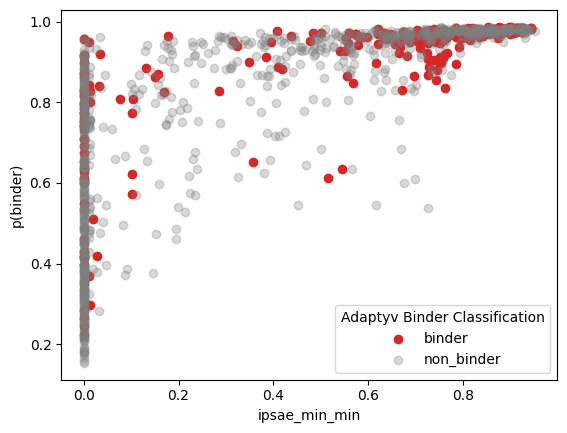

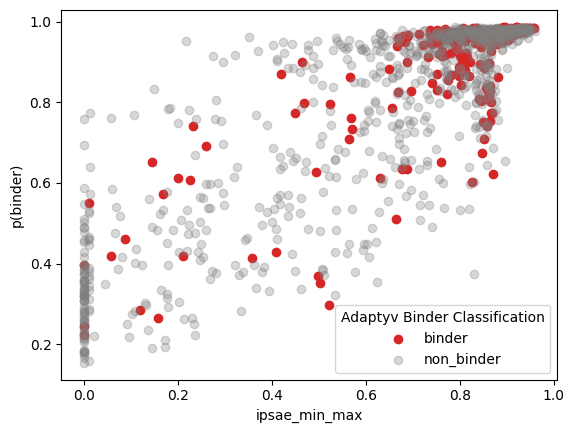

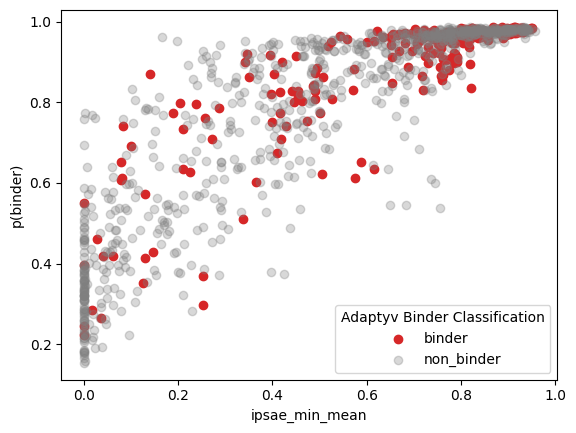

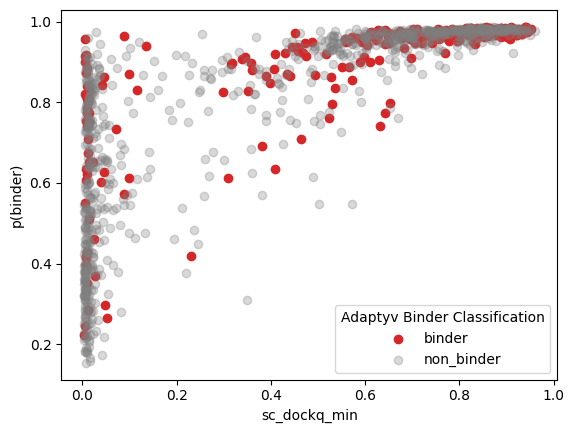

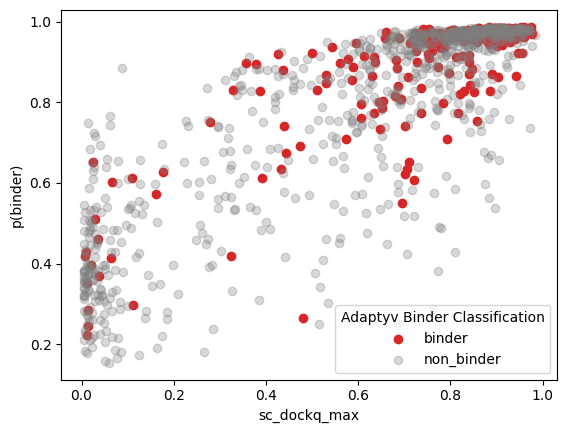

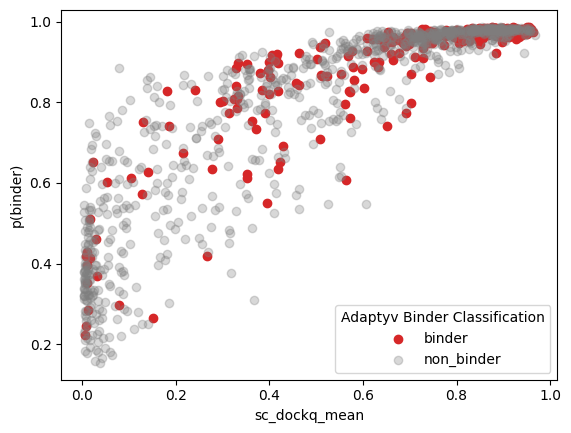

In [14]:
## Scatterplots colored by true binder class
import matplotlib.pyplot as plt

CLASS_COLORS = {"non_binder": "tab:grey", "binder": "tab:red"}
CLASS_ALPHAS = {"non_binder": 0.3, "binder": 1}


def plot_by_true_class(x_column: str) -> None:
    fig, ax = plt.subplots()
    for label, group in scored_df.groupby("y_true"):
        ax.scatter(
            group[x_column],
            group["p_binder"],
            color=CLASS_COLORS[label],
            alpha=CLASS_ALPHAS[label],
            label=label,
        )
    ax.set(xlabel=x_column, ylabel="p(binder)")
    ax.legend(title="Adaptyv Binder Classification")
    plt.show()


plot_by_true_class("ipsae_min_min")
plot_by_true_class("ipsae_min_max")
plot_by_true_class("ipsae_min_mean")
plot_by_true_class("sc_dockq_min")
plot_by_true_class("sc_dockq_max")
plot_by_true_class("sc_dockq_mean")